# Voltage data — visualisation and interpretation
**Greencell internship assignment (July 2026)**

Dataset: `data/Sample_Data.csv` — two columns, `Values` (voltage, V) and `Timestamp`.

This notebook works through every part of the brief:

| Part | Where |
|---|---|
| 1a — plot voltage vs timestamp | §2 |
| 1b — 5-day moving average | §3 |
| 1c — local peaks and lows, tabulated | §4 |
| 1d — every instance the voltage went below 20 V | §5 |
| Bonus 2 — where the downward slope accelerates | §6 |
| Bonus 3 — hosted version | see `README.md` |

The reusable logic lives in `analysis.py` so the same code backs the notebook,
the Excel builder and the hosted dashboard.

## 1. Import the data into a DataFrame and clean it

Three things in this file need handling before anything is plotted:

1. **The timestamp is a string until you parse it.** The supplied file happens to
   already be in date order (I checked), but a chart drawn against a *text* axis
   sorts lexically, so `01-07-2024` lands before `26-06-2024` — which is exactly
   what happened to the annexure figure. Parse to datetime, then sort on it.
2. **Timestamps are truncated to the minute**, and the logger samples every
   ~15–20 s, so 3–5 rows share each minute.
3. **The logger drops out** — 90 gaps longer than 5 minutes, the longest 5.6 hours,
   splitting the week into 79 stretches of continuous recording. Only holes whose
   whole length is ≤5 min are bridged (`interpolate(limit=5)` would instead fill the
   first 5 minutes of *every* outage), so no figure here contains invented data.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import analysis

raw = analysis.load_data()          # parse day-first dates, sort chronologically
minute = analysis.build_minute_series(raw)   # 1-min grid, gaps preserved
minute, raw = analysis.add_moving_averages(minute, raw)

print(raw.dtypes)
raw.head()

Voltage                     int64
Timestamp          datetime64[us]
MA_1000_samples           float64
MA_5000_samples           float64
dtype: object


,Voltage,Timestamp,MA_1000_samples,MA_5000_samples
0,100,2024-06-26 06:17:00,100.0,100.0
1,100,2024-06-26 06:18:00,100.0,100.0
2,100,2024-06-26 06:18:00,100.0,100.0
3,100,2024-06-26 06:18:00,100.0,100.0
4,100,2024-06-26 06:19:00,100.0,100.0


In [2]:
analysis.data_quality_report(raw, minute)

,Metric,Value
0,Raw rows in file,21919
1,Distinct timestamps (minute resolution),5934
2,Readings per minute (mean),3.69
3,Readings per minute (median),4.0
4,First reading,2024-06-26 06:17:00
5,Last reading,2024-07-03 10:30:00
6,Span covered,7 days 04:13:00
7,Minimum voltage,25
8,Maximum voltage,100
9,Mean voltage,67.33


## 2. Plot the same chart as in Excel

Voltage on the y-axis, timestamp on the x-axis, plus the straight-line trendline
Excel draws and a 60-minute moving average for readability.

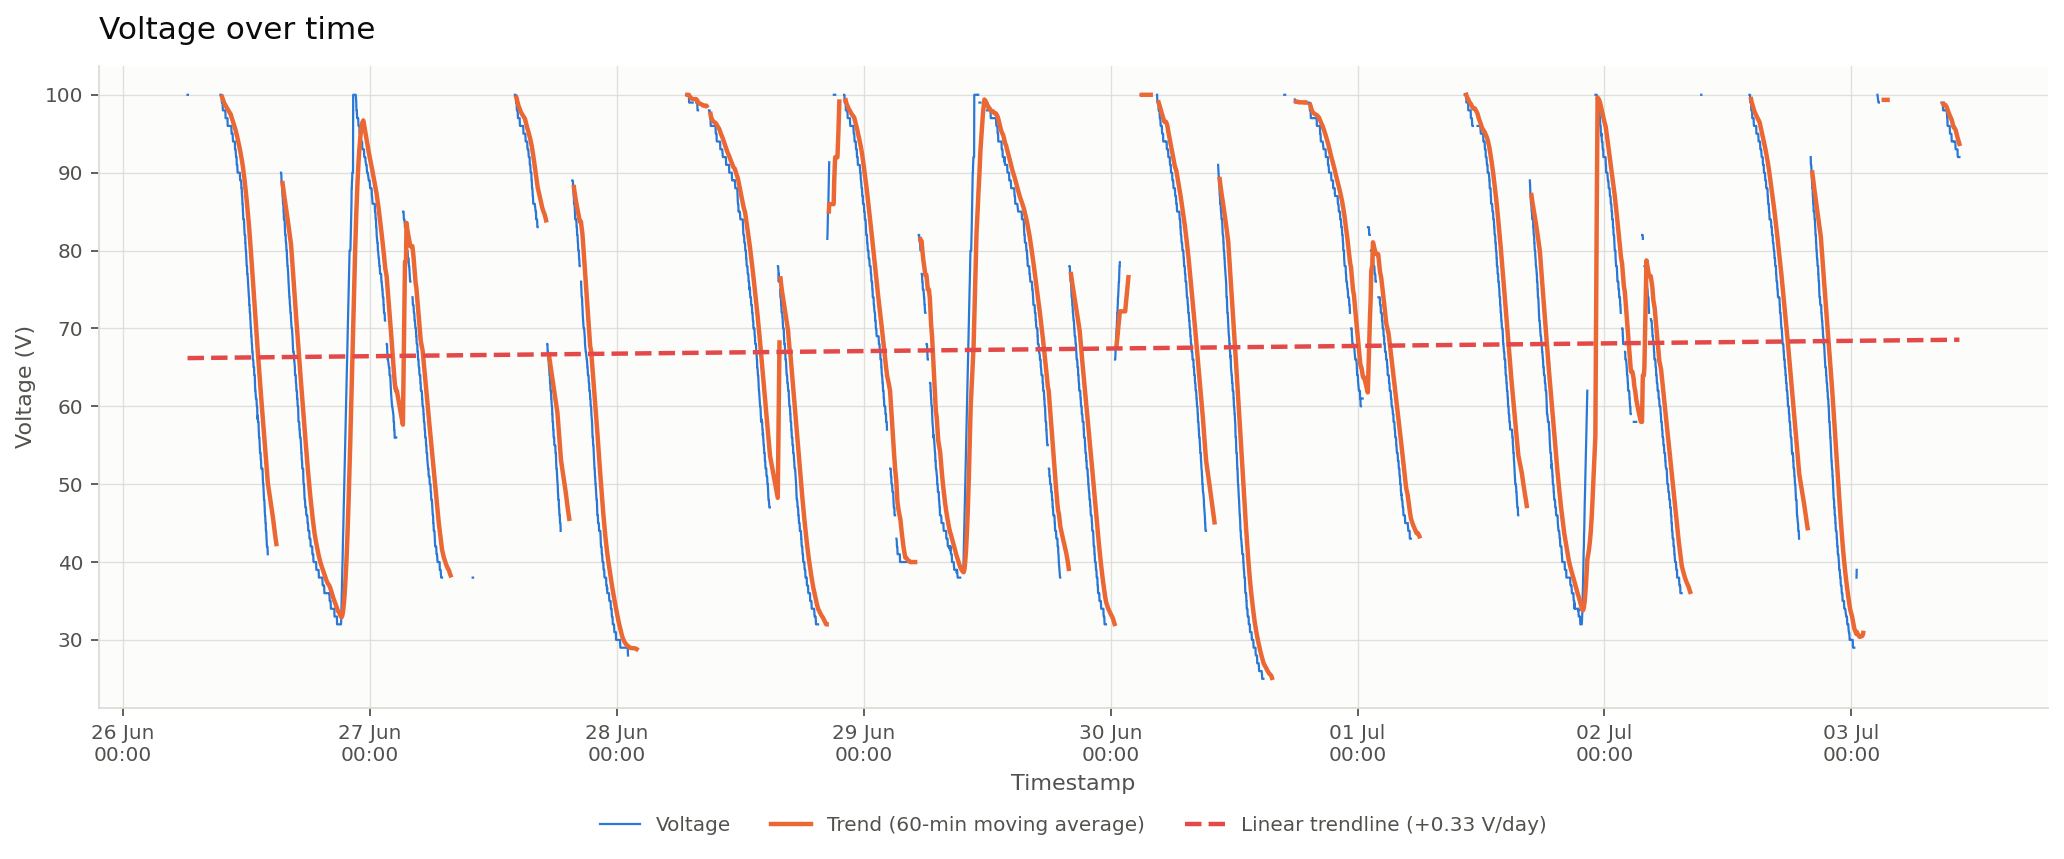

Linear trendline: Voltage = +0.3289 V/day x days + 66.19 V
Net change across the 7.2-day record: +2.36 V  ->  effectively flat.


In [3]:
%matplotlib inline
analysis.plot_basic(minute, "figures/fig1_voltage_vs_time.png", raw)
from IPython.display import Image, display
display(Image("figures/fig1_voltage_vs_time.png"))

# fit over the raw readings, which is what Excel's trendline does
trend, slope, intercept = analysis.linear_trend(minute, raw)
print(f"Linear trendline: Voltage = {slope:+.4f} V/day x days + {intercept:.2f} V")
print(f"Net change across the {len(minute)/1440:.1f}-day record: "
      f"{slope*len(minute)/1440:+.2f} V  ->  effectively flat.")

## 3. Moving averages

The brief asks for a **5-day** moving average. On a 7-day record that window only
becomes defined part-way through and flattens the signal almost completely, so the
1000-sample and 5000-sample windows from the annexure figure are plotted alongside
it — those are the ones that actually describe the behaviour.

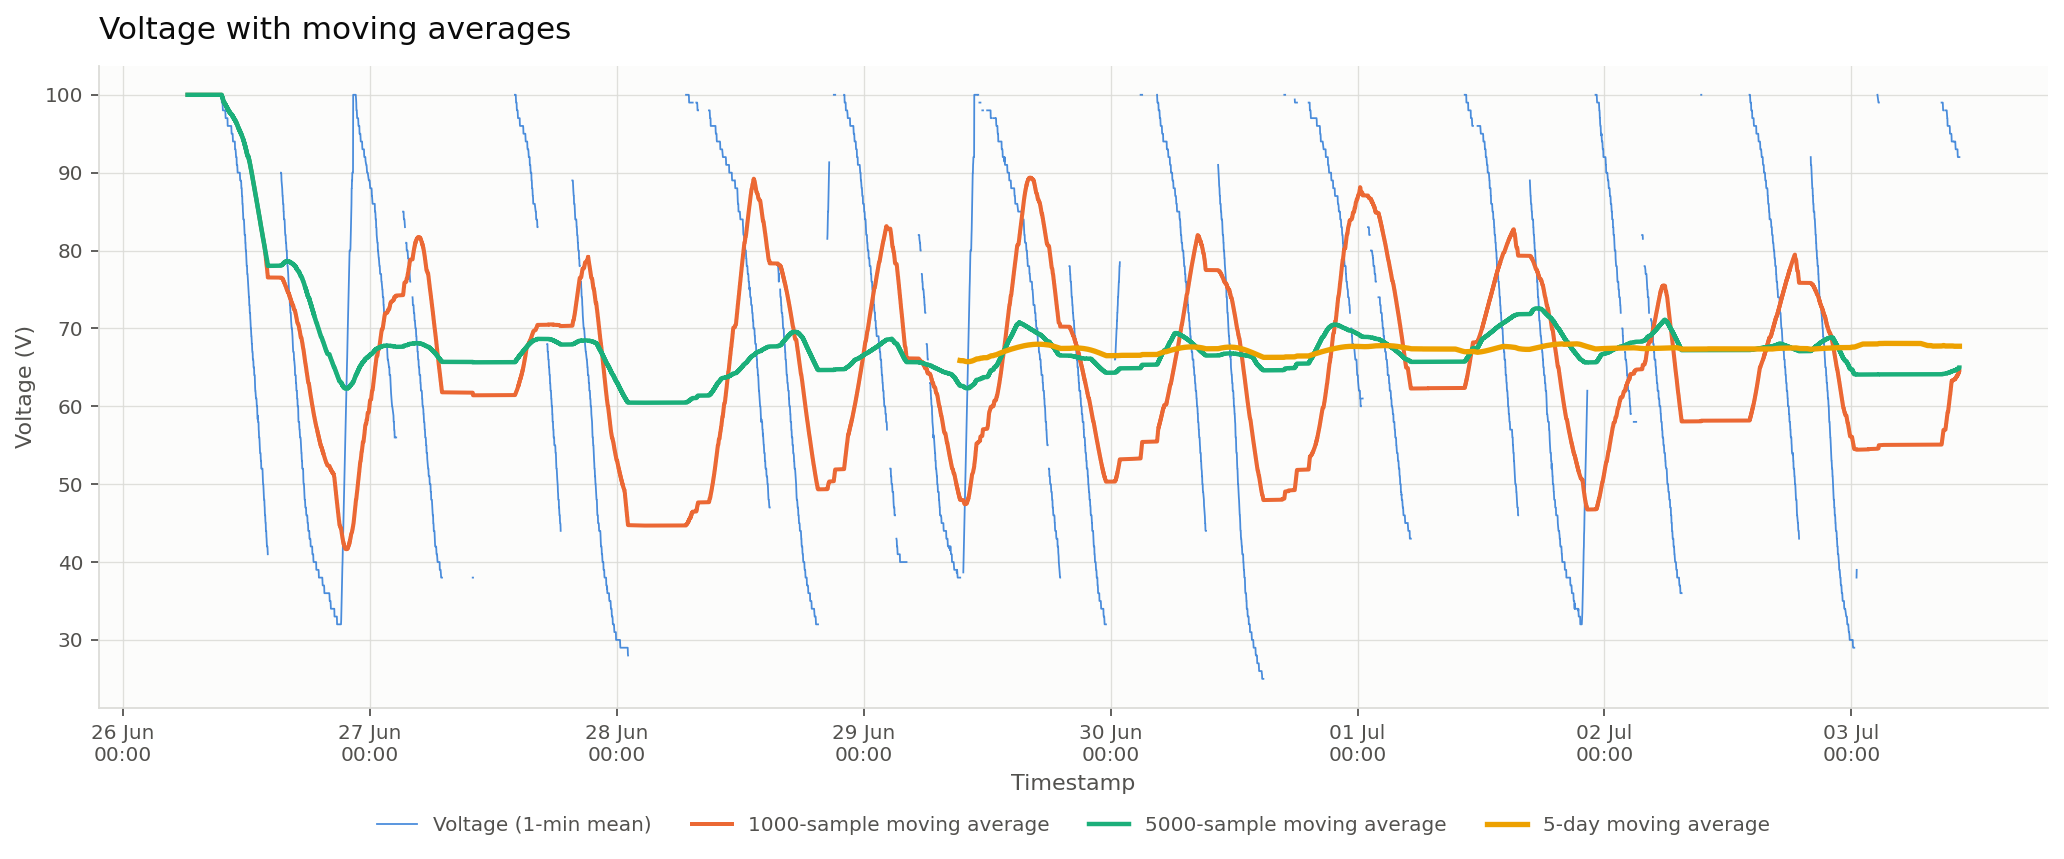

In [4]:
analysis.plot_moving_averages(minute, raw, "figures/fig2_moving_averages.png")
display(Image("figures/fig2_moving_averages.png"))

## 4. Local peaks and lows

`scipy.signal.find_peaks` on a 15-minute median-smoothed series, requiring 10 V of
prominence and 2 hours of separation — otherwise the 1 V quantisation of the logger
produces hundreds of meaningless micro-peaks. Each accepted point is snapped back to
the true extremum in the recorded neighbourhood.

Detection runs over the **recorded minutes only**. Filling the gaps first (with the
mean, say) makes `find_peaks` measure prominence against a fabricated plateau, and
every gap edge then scores as a turning point — you get pairs of consecutive
"peaks", which no real signal contains. With the gaps dropped the result alternates
peak–low–peak–low without exception. Points whose neighbouring reading sits across
an outage are flagged, since the true turn may have happened unobserved.

In [5]:
tp = analysis.find_turning_points(minute)
print(f"{(tp.Type == 'Peak (local high)').sum()} peaks, "
      f"{(tp.Type == 'Low (local minimum)').sum()} lows")
tp

21 peaks, 22 lows


,No.,Timestamp,Voltage,Type,Note
0,1,2024-06-26 14:05:00,41.0,Low (local minimum),next to a data gap
1,2,2024-06-26 15:22:00,90.0,Peak (local high),next to a data gap
2,3,2024-06-26 20:49:00,32.0,Low (local minimum),
3,4,2024-06-26 22:23:00,100.0,Peak (local high),
4,5,2024-06-27 02:25:00,56.0,Low (local minimum),next to a data gap
5,6,2024-06-27 03:14:00,85.0,Peak (local high),next to a data gap
6,7,2024-06-27 06:56:00,38.0,Low (local minimum),
7,8,2024-06-27 14:06:00,100.0,Peak (local high),next to a data gap
8,9,2024-06-27 18:33:00,44.0,Low (local minimum),next to a data gap
9,10,2024-06-27 19:41:00,89.0,Peak (local high),next to a data gap


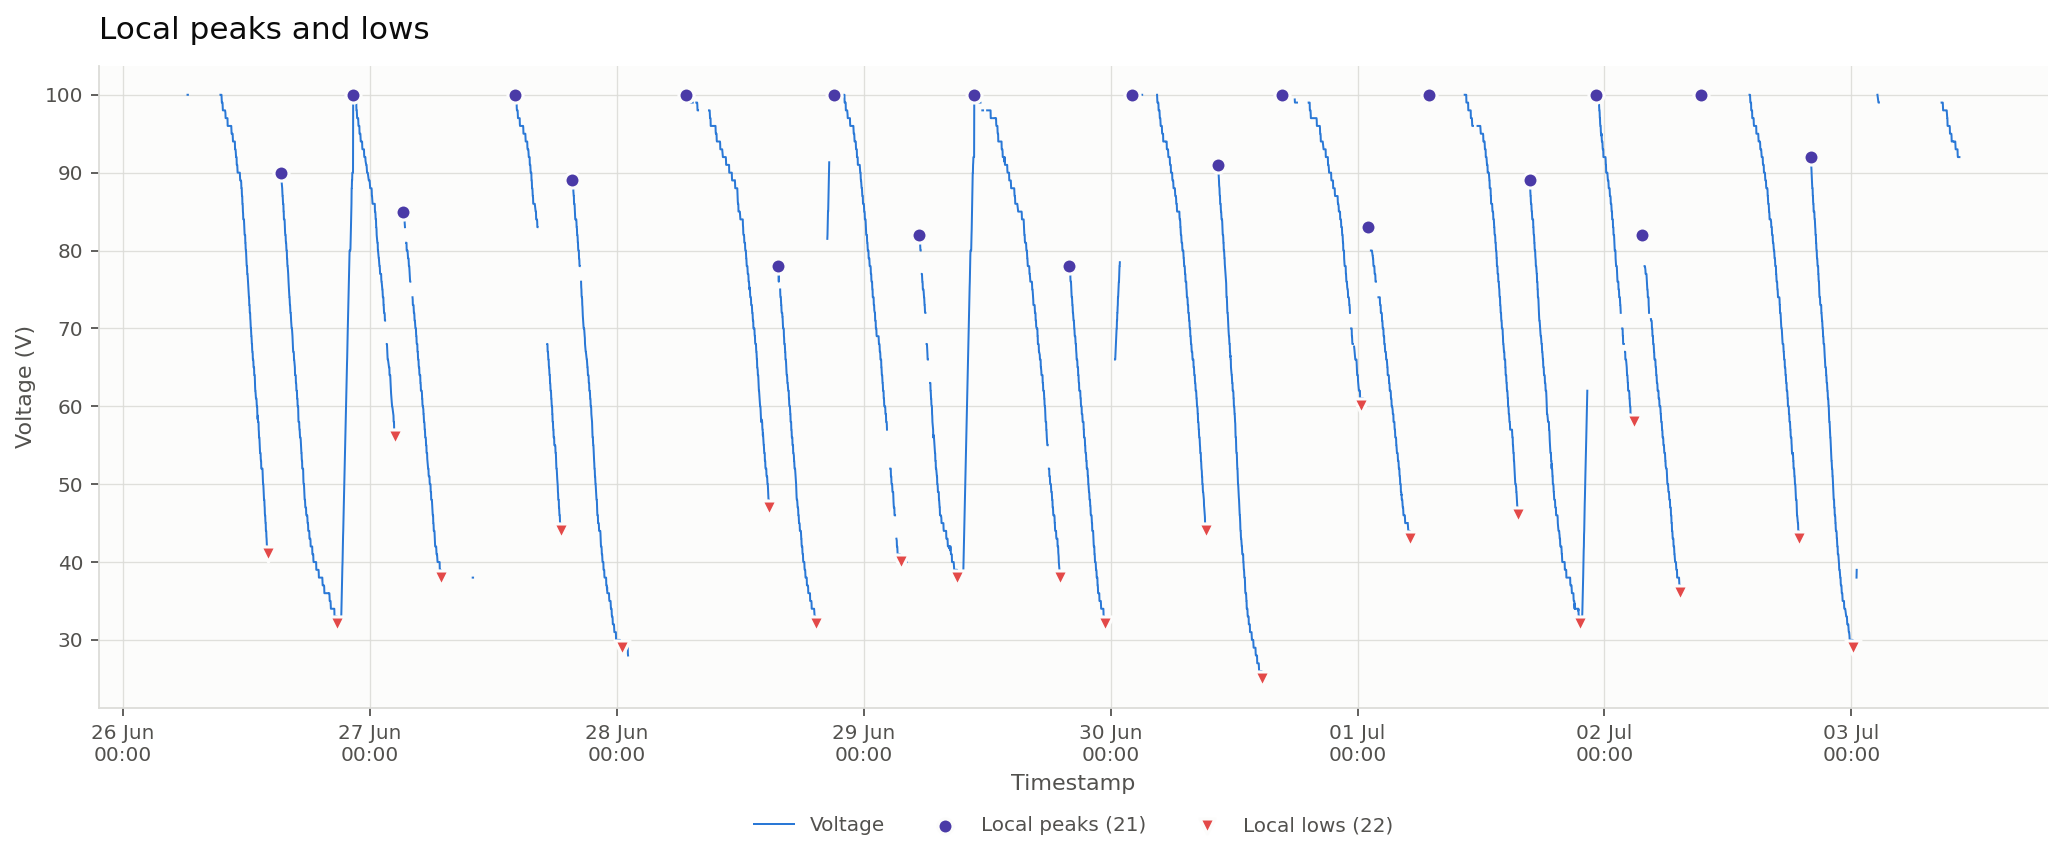

In [6]:
analysis.plot_turning_points(minute, tp, "figures/fig3_peaks_and_lows.png")
display(Image("figures/fig3_peaks_and_lows.png"))

Pairing each peak with the low that follows it gives one row per discharge cycle
— the shape the whole week is made of.

In [7]:
cycles = analysis.cycle_table(tp)
cycles

,Cycle,Peak time,Peak V,Low time,Low V,Drop (V),Duration (h),Avg rate (V/h)
0,1,2024-06-26 15:22:00,90.0,2024-06-26 20:49:00,32.0,58.0,5.45,-10.64
1,2,2024-06-26 22:23:00,100.0,2024-06-27 02:25:00,56.0,44.0,4.03,-10.91
2,3,2024-06-27 03:14:00,85.0,2024-06-27 06:56:00,38.0,47.0,3.70,-12.70
3,4,2024-06-27 14:06:00,100.0,2024-06-27 18:33:00,44.0,56.0,4.45,-12.58
4,5,2024-06-27 19:41:00,89.0,2024-06-28 00:29:00,29.0,60.0,4.80,-12.50
5,6,2024-06-28 06:44:00,100.0,2024-06-28 14:50:00,47.0,53.0,8.10,-6.54
6,7,2024-06-28 15:40:00,78.0,2024-06-28 19:22:00,32.0,46.0,3.70,-12.43
7,8,2024-06-28 21:06:00,100.0,2024-06-29 03:36:00,40.0,60.0,6.50,-9.23
8,9,2024-06-29 05:21:00,82.0,2024-06-29 09:07:00,38.0,44.0,3.77,-11.68
9,10,2024-06-29 10:45:00,100.0,2024-06-29 19:05:00,38.0,62.0,8.33,-7.44


In [8]:
print(f"{len(cycles)} discharge cycles")
print(f"Mean depth   : {cycles['Drop (V)'].mean():.1f} V "
      f"(range {cycles['Drop (V)'].min():.0f}-{cycles['Drop (V)'].max():.0f} V)")
print(f"Mean duration: {cycles['Duration (h)'].mean():.2f} h "
      f"(range {cycles['Duration (h)'].min():.1f}-{cycles['Duration (h)'].max():.1f} h)")
print(f"Mean rate    : {cycles['Avg rate (V/h)'].mean():.2f} V/h")

21 discharge cycles
Mean depth   : 52.2 V (range 40-66 V)
Mean duration: 5.43 h (range 3.4-9.5 h)
Mean rate    : -10.54 V/h


## 5. Every instance the voltage went below 20 V

Consecutive readings under the threshold are grouped into **episodes**, so one
physical dip is one instance rather than one instance per reading.

In [9]:
below20 = analysis.threshold_episodes(raw, 20.0)   # episodes, split at outages
print(f"Instances below 20 V: {len(below20)}")
print(f"Lowest reading anywhere in the file: {raw['Voltage'].min():.0f} V")
below20

Instances below 20 V: 0
Lowest reading anywhere in the file: 25 V


,Instance,Start,End,Duration (min),Minutes recorded,Minimum V,Time at minimum,Readings


**The answer is zero** — the series never goes below 20 V, because its minimum is
25 V. To show the detector is doing real work rather than silently returning an
empty frame, here is the identical test at 30 V:

In [10]:
analysis.threshold_episodes(raw, 30.0)

,Instance,Start,End,Duration (min),Minutes recorded,Minimum V,Time at minimum,Readings
0,1,2024-06-28 00:20:00,2024-06-28 01:06:00,46.0,47,28.0,2024-06-28 01:05:00,179
1,2,2024-06-28 02:44:00,2024-06-28 02:44:00,0.0,1,28.0,2024-06-28 02:44:00,1
2,3,2024-06-30 13:53:00,2024-06-30 14:51:00,58.0,56,25.0,2024-06-30 14:42:00,210
3,4,2024-07-03 00:09:00,2024-07-03 00:17:00,8.0,9,29.0,2024-07-03 00:09:00,31


## 6. Bonus — where does the downward slope accelerate?

Two derivatives:

* **slope** — a centred 31-minute least-squares fit at every minute, in V/hour.
* **curvature** — the change in that slope from one minute to the next.

Inside each peak→low cycle, an *acceleration* is a stretch where the voltage is
already falling (`slope < 0`) **and** the fall is getting steeper
(`d(slope)/dt < 0`). Each contiguous stretch is reported once, at its onset;
stretches shorter than 15 minutes or steepening by less than 2 V/h are treated as
logger noise.

In [11]:
slope_s = analysis.slope_series(minute)
accel = analysis.find_slope_acceleration(minute, tp, slope_s)
print(f"{len(accel)} acceleration episodes across {len(cycles)} cycles")
accel

38 acceleration episodes across 21 cycles


,No.,Cycle,Acceleration starts,Acceleration ends,Duration (min),Voltage at onset,Slope at onset (V/h),Steepest slope reached (V/h),Slope change (V/h)
0,1,1,2024-06-26 15:45:00,2024-06-26 16:04:00,19.0,83.0,-18.13,-20.87,-2.74
1,2,2,2024-06-27 00:18:00,2024-06-27 00:40:00,22.0,86.0,-6.53,-16.84,-10.31
2,3,3,2024-06-27 05:52:00,2024-06-27 06:07:00,15.0,50.0,-12.55,-16.06,-3.50
3,4,4,2024-06-27 14:52:00,2024-06-27 15:42:00,50.0,96.0,-2.78,-14.01,-11.23
4,5,5,2024-06-27 21:12:00,2024-06-27 21:43:00,31.0,64.0,-13.69,-22.39,-8.70
5,6,5,2024-06-27 23:15:00,2024-06-27 23:30:00,15.0,36.0,-5.95,-8.83,-2.88
6,7,6,2024-06-28 12:04:00,2024-06-28 12:25:00,21.0,84.0,-4.84,-12.90,-8.06
7,8,6,2024-06-28 13:17:00,2024-06-28 13:46:00,29.0,70.0,-12.47,-18.67,-6.20
8,9,8,2024-06-28 22:47:00,2024-06-28 23:13:00,26.0,96.0,-2.96,-9.58,-6.62
9,10,8,2024-06-28 23:29:00,2024-06-28 23:49:00,20.0,91.0,-7.74,-12.76,-5.02


In [12]:
print("Timestamps where the downward slope accelerates:")
for t in accel["Acceleration starts"]:
    print("  ", t.strftime("%d-%m-%Y %H:%M"))

Timestamps where the downward slope accelerates:
   26-06-2024 15:45
   27-06-2024 00:18
   27-06-2024 05:52
   27-06-2024 14:52
   27-06-2024 21:12
   27-06-2024 23:15
   28-06-2024 12:04
   28-06-2024 13:17
   28-06-2024 22:47
   28-06-2024 23:29
   29-06-2024 00:00
   29-06-2024 00:35
   29-06-2024 01:25
   29-06-2024 08:19
   29-06-2024 14:26
   29-06-2024 15:12
   29-06-2024 16:13
   29-06-2024 17:16
   29-06-2024 21:11
   30-06-2024 06:33
   30-06-2024 07:04
   30-06-2024 08:01
   30-06-2024 10:50
   30-06-2024 11:51
   30-06-2024 19:50
   30-06-2024 21:55
   01-07-2024 11:57
   01-07-2024 13:07
   01-07-2024 14:56
   01-07-2024 17:05
   01-07-2024 20:31
   02-07-2024 00:26
   02-07-2024 06:15
   02-07-2024 14:45
   02-07-2024 16:13
   02-07-2024 16:57
   02-07-2024 18:17
   02-07-2024 21:32


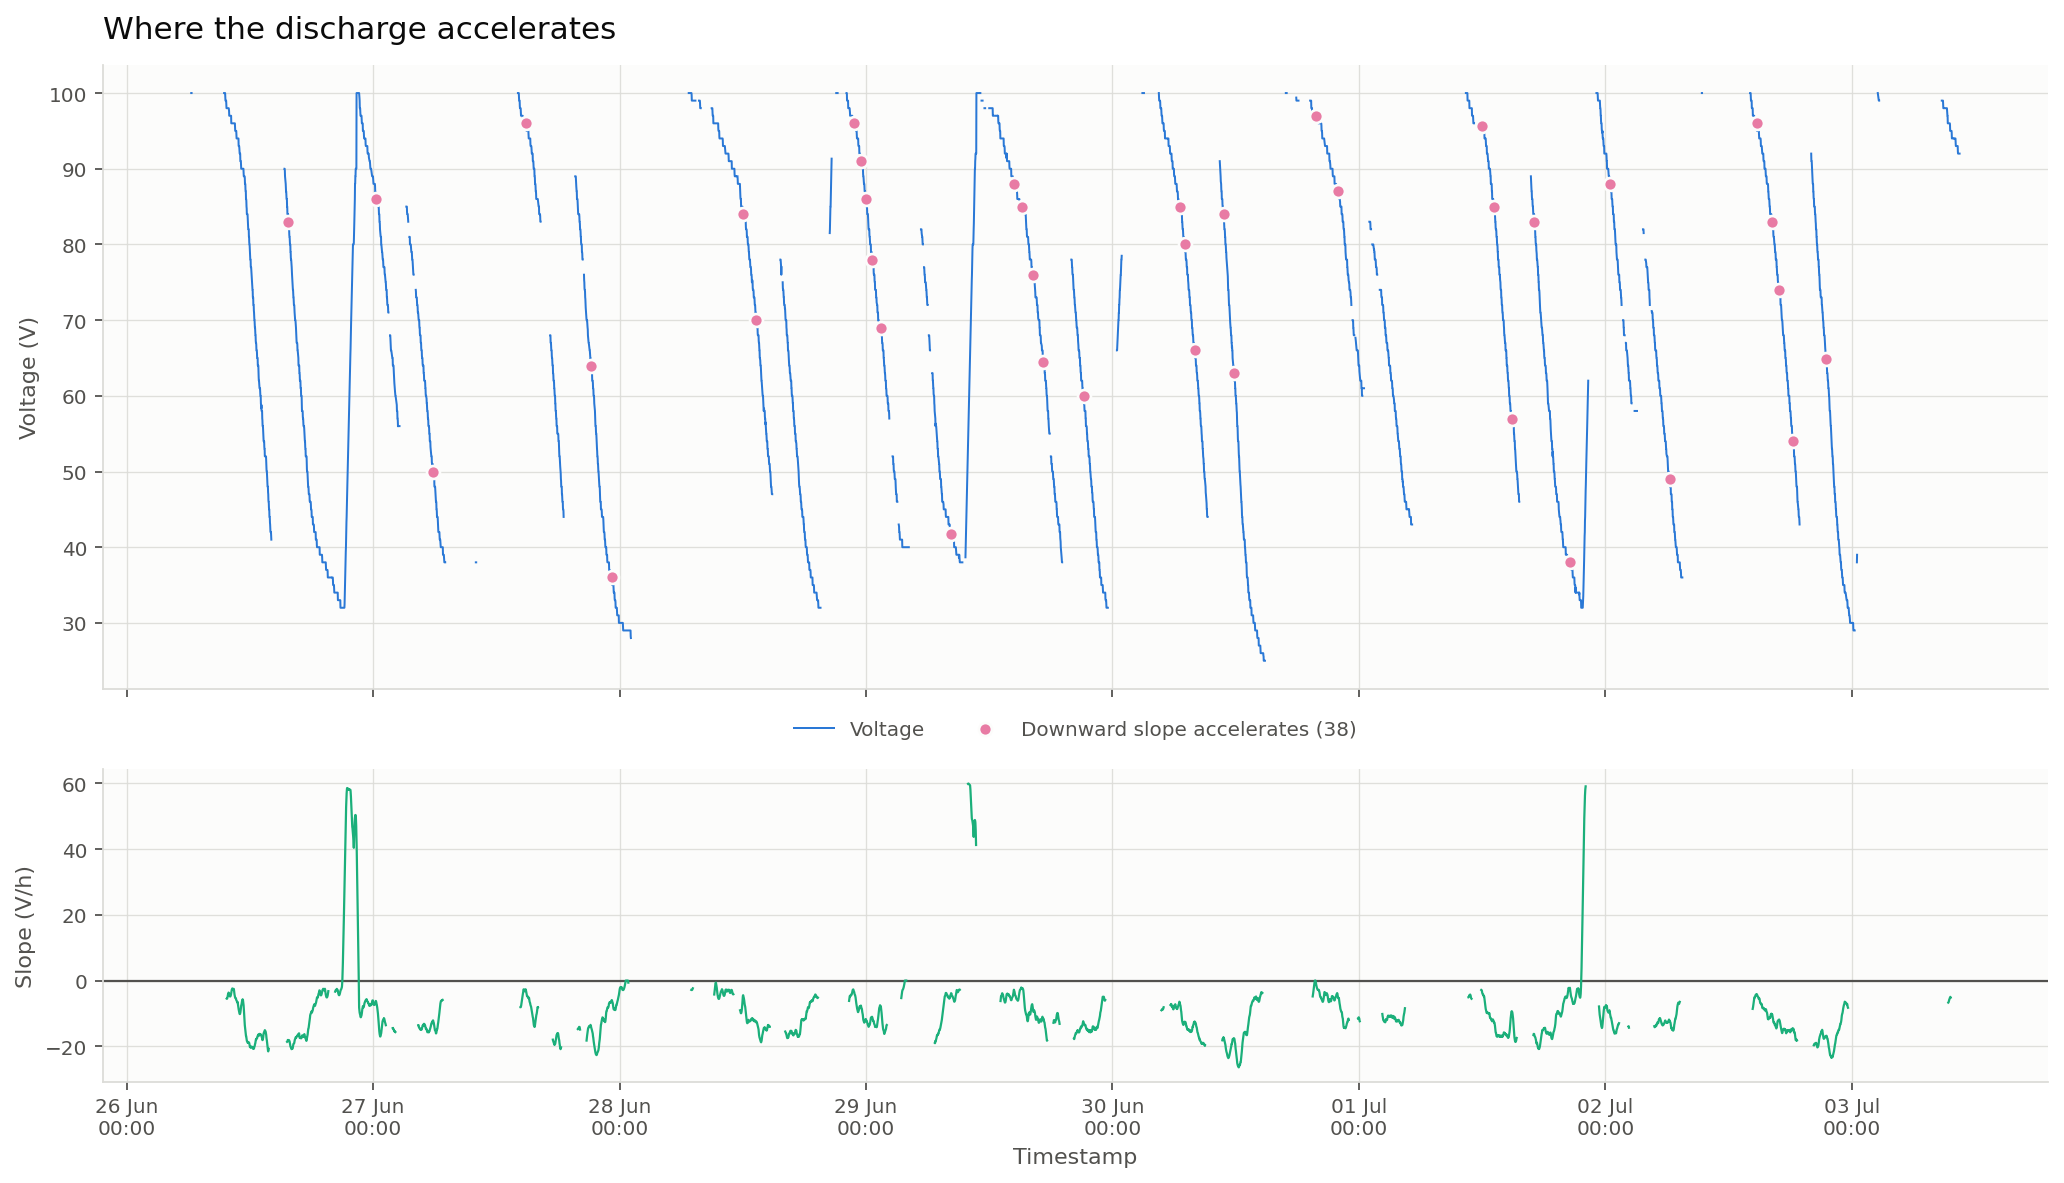

In [13]:
analysis.plot_acceleration(minute, slope_s, accel,
                           "figures/fig4_slope_acceleration.png")
display(Image("figures/fig4_slope_acceleration.png"))

## 7. Interactive version

The same chart as a Plotly figure — hover for values, drag to zoom. This is also
what the hosted Streamlit dashboard serves (`app.py`, deployment steps in
`README.md`).

In [14]:
analysis.plot_interactive(minute, raw, tp, accel,
                          "figures/interactive_chart.html")
print("Written to figures/interactive_chart.html")

Written to figures/interactive_chart.html


## 8. Interpretation

In [15]:
import build_excel
res = dict(raw=raw, minute=minute, tp=tp, cycles=cycles, accel=accel)
for i, s in enumerate(build_excel.interpretation_sentences(res), 1):
    print(f"{i}. {s}\n")

1. The record covers 7.2 days (21,919 readings, roughly one every 15-20 seconds) and the voltage never leaves the band 25-100 V, so the series is not a drifting signal but a repeating duty cycle.

2. That cycle is a sawtooth: a fast rise back towards 100 V followed by a long, almost straight decline - 21 complete discharge cycles are visible, each losing on average 52 V over 5.4 hours (-10.5 V/h).

3. Because charge and discharge repeat around the same mean, the linear trendline is nearly flat (+0.33 V/day over the week, R-squared about 0.001) - it says the asset is being cycled consistently rather than degrading, and it is the moving average, not the straight line, that carries the information here.

4. The tops are capped: 10 of the 21 recorded highs sit at exactly 100 V and the rest are lower only because the recharge itself fell inside a logging gap, while the lows scatter widely from 25 V to 60 V - the unit is always taken back to full, but how deeply it is drained first varies wi